# 0. LangChain 설치


- 의존성 라이브러리 설치

In [110]:
# Install required packages into the active Jupyter kernel (use %pip, not !pip)
%pip install -qU pip
# Upgrade pip
%pip install -qU "openai>=1.40.0" "langchain>=0.2.10" "langchain-openai>=0.1.21" "langchain-community>=0.2.10"
# langchain-community has additional community-contributed modules, including advanced retrievers
%pip install -qU "tiktoken>=0.7.0" "pypdf>=4.2.0" "chromadb>=0.5.5" "lark>=1.1.9"

# Note:
# - faiss-cpu on Windows + Python 3.12 often fails to install via pip. Use Chroma (installed above) instead.
# - If you must use FAISS, prefer Python 3.11 or conda prebuilt packages.

# Quick sanity check
import importlib
for pkg in ["langchain", "langchain_openai", "openai", "chromadb", "tiktoken", "pypdf", "lark"]:
    importlib.import_module(pkg)
print("✅ Packages installed and importable.")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
✅ Packages installed and importable.


- API 키 등록

In [111]:
import os

api_key = "sk-f_Ae5L9K9tiyYUCTa8_wJuF5c194uBcz2IofaZNBxwT3BlbkFJqTsPggjlugRL-et4nfI_ci3QeYCo3NGiuGF1RPNcEA"
os.environ["OPENAI_API_KEY"] = api_key

# 1. 간단한 챗봇 만들기

In [112]:
from langchain_openai import ChatOpenAI # ChatLLM 클래스
from langchain.callbacks.streaming_stdout import StreamingStdOutCallbackHandler # 스트리밍 출력 핸들러      

In [113]:
# LLM 초기화
LLM = ChatOpenAI(
    model = "gpt-4.1-mini", 
    temperature= 0, # 창의성 조절 (0~1)
    max_tokens = 1000, # 최대 토큰 수
    streaming = False,
    # 스트리밍 출력 비활성화 스트리밍이란?  
    # streaming=True로 설정하면 LLM 응답이 한 번에 출력되는 것이 아니라, 토큰 단위로 실시간(스트리밍)으로 출력됨
    # streaming=False(기본값)이면 응답이 모두 생성된 후 한 번에 출력됨
    # 실시간 응답이 필요한 경우 True, 일반적인 경우 False로 설정
    callbacks = [StreamingStdOutCallbackHandler()]
)

In [114]:
# 무한루프문으로 챗봇 기능 구현
while True:
    query = input("\n\n질문을 입력하세요 (종료: exit) : ")
    if query.lower() == "exit": # 종료 조건
        print("챗봇을 종료합니다.")
        break
    response = LLM.invoke(query) # 질문에 대한 응답 생성
    print("\n챗봇 응답: ", response) # 챗봇 응답 출력

챗봇을 종료합니다.


In [115]:
# 무한루프문으로 챗봇 기능 구현
while True:
    q = input("입력 >> ").strip()

    # 종료 조건
    if q.lower() in ("exit", "quit"):  # 'exit' 또는 'quit'로 종료
        break

    # 모델 응답 출력
    try:
        res = LLM.invoke(q)
        # streaming=True이면 토큰이 실시간으로 출력되지만, 최종 응답도 명시적으로 출력
        if hasattr(res, "content"):
            print("\n" + res.content + "\n")
        else:
            print("\n" + str(res) + "\n")
    except Exception as e:
        print(f"[오류] {e}")




## 1.1. 이전 대화 내용을 저장해서 연결된 대화가 되도록 만들어보기
- ConversationChain : LLM 모델에 메모리를 추가하는 기능

In [116]:
from langchain.chains import ConversationChain # 대화 체인을 구성하는 클래스
from langchain.memory import ConversationBufferMemory # 대화의 역사를 저장하기 위한 클래스

In [117]:
# 위 모델 활용
LLM

ChatOpenAI(callbacks=[<langchain_core.callbacks.streaming_stdout.StreamingStdOutCallbackHandler object at 0x0000017C97CFEF90>], client=<openai.resources.chat.completions.completions.Completions object at 0x0000017C968C4B90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000017C97CD2870>, root_client=<openai.OpenAI object at 0x0000017C97D05D30>, root_async_client=<openai.AsyncOpenAI object at 0x0000017C96897D10>, model_name='gpt-4.1-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1000)

In [118]:
# 1. 대화 체인 구성
chain = ConversationChain(
    llm = LLM,
    memory = ConversationBufferMemory()
)

In [119]:
# 2. 무한루프 수행
while True :
  q = input("입력 >>")

  if q == "exit" :
    break

    # 모델 응답 출력
    res = chain.invoke(q)["response"]
    print(res) # 개행용

#### `ConversationChain` 클래스가 더 이상 권장되지 않음

> - LangChain 0.2.7 버전부터 사용 중지(deprecated)로, 향후 1.0 버전에서 삭제될 예정
> - 아래 Memory 클래스도 마찬가지

| **Memory Type**                                                                 | **설명**                                                                                                                                                               |
|---------------------------------------------------------------------------------|------------------------------------------------------------------------------------------------------------------------------------------------------------------------|
| ConversationBufferMemory                                 | 이전 대화 내용을 그대로 저장하는 메모리                                                                                                                                |
| ConversationBufferWindowMemory  | 윈도우 크기 *k*를 지정하면 최근 *k*개의 대화만 기억하고, 그 이전 대화는 삭제됨                                                                                            |
| ConversationTokenBufferMemory   | 최근 대화 히스토리를 버퍼에 저장하며, 대화 개수가 아닌 토큰 길이를 기준으로 대화내용 플러시 시기를 설정함                                                               |
| ConversationSummaryMemory       | 이전 대화 내용을 그대로 기억하지 않고 요약해서 저장함. 긴 대화에서 토큰 사용량을 줄이는 데 유용                                                                               |
| ConversationSummaryBufferMemory                          | ConversationSummaryMemory의 확장판 <br> 이전 대화를 요약해 저장하면서 최근 대화는 최대 토큰 범위 내에서 유지하도록 하며, 최대 토큰 길이를 지정할 수 있음<br>토큰을 줄여 API 활용 시 비용을 최소화하는 효율적인 메모리                  |
| VectorStoreRetrieverMemory   | 대화 내역을 벡터 저장소에 저장하고, 입력을 기반으로 과거 대화 중 가장 관련성 높은 부분을 검색함                                                                            |

## 1.2. <font color=red>RunnableWithMessageHistory</font> : LangChain의 새로운 채팅 기록(메모리) 모듈


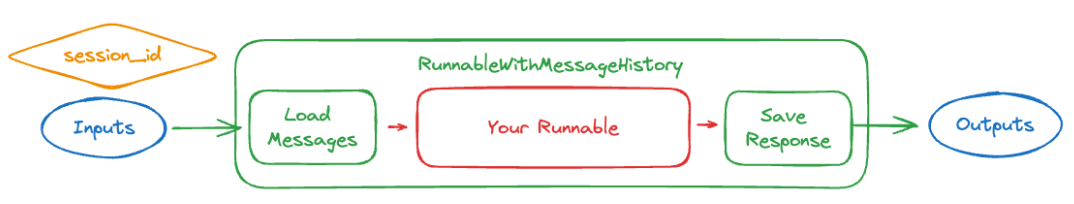

### 1.2.1. RunnableWithMessageHistory 개념도

> **세션(session-id) 기반으로 메시지 관리**  
- 각 대화를 구분하기 위해 session-id(세션 ID)를 사용  
- 세션별로 메시지를 저장하고, 필요한 정보를 불러오거나 다시 기록

> **Load Messages**  
- 과거에 주고받았던 메시지(질문, 응답 등)를 불러옴  
- 이 과거 대화 내용이 “대화의 맥락”이 됨

> **Your Runnable(또는 chain)**  
- 실제로 모델이 응답을 생성하거나, 특정 로직을 수행하는 핵심 부분  
- 입력 메시지와 과거 대화 내용을 활용해 결과(응답)를 생성

> **Save Response**  
- 생성된 응답(결과)을 다시 메시지 히스토리에 저장  
- 이후 대화를 진행할 때, 이 응답이 과거 대화로 인식됨

> **Outputs**  
- 최종적으로 사용자가 확인할 수 있는 결과(답변, 메시지 등)  
- 다음 입력이 들어오기 전까지, 이전 메시지들이 히스토리에 누적되어 맥락이 유지됨

In [120]:
# 대화 기록과 연동되는 체인들을 실행할 수 있는 도구
from langchain_core.runnables.history import RunnableWithMessageHistory

# MessagesPlaceholder: 프롬프트 내에서 대화
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder

# BaseChatMessageHistory: 대화 기록을 저장하고 관리하는 기본 클래스
from langchain_core.chat_history import BaseChatMessageHistory

# ChatMessageHistory: 대화 기록을 파일에 저장하고 불러오는 클래스
from langchain_community.chat_message_histories import ChatMessageHistory

# StrOutputParser: 모델의 출력을 문자열로 파싱하는 클래스
from langchain_core.output_parsers import StrOutputParser

 

In [121]:
# 위 모델 활용
LLM

ChatOpenAI(callbacks=[<langchain_core.callbacks.streaming_stdout.StreamingStdOutCallbackHandler object at 0x0000017C97CFEF90>], client=<openai.resources.chat.completions.completions.Completions object at 0x0000017C968C4B90>, async_client=<openai.resources.chat.completions.completions.AsyncCompletions object at 0x0000017C97CD2870>, root_client=<openai.OpenAI object at 0x0000017C97D05D30>, root_async_client=<openai.AsyncOpenAI object at 0x0000017C96897D10>, model_name='gpt-4.1-mini', temperature=0.0, model_kwargs={}, openai_api_key=SecretStr('**********'), max_tokens=1000)

In [122]:
# 1. 메세지 리스트 생성 & 템플릿 생성
messages = [
    ("system", "너는 신뢰할 수 있는 AI 비서야. 사용자가 질문하면 친절하고 자세하게 답변해줘."), # system: 모델의 역할 정의
    MessagesPlaceholder(variable_name="history"), # history: 대화 기록
    ("human", "{input}") # human: 사용자의 질문
]

# ChatPromptTemplate: 대화 프롬프트 템플릿
prompt = ChatPromptTemplate.from_messages(messages)

In [123]:
# 2. 체인 구성 

chain = prompt | LLM | StrOutputParser()

In [124]:
# 3. 세션(하나의 대화내용) 기록할 수 있는 딕셔너리 초기화
store = {} # 세션ID : 대화내용 객체 

In [125]:
# 4. 세션 ID 기반 대화 기록을 관리하는 함수 정의 => 
# # session_ids: 동적자료형 => 문제점 : 가독성이 떨어진다. so 내부처리되느지 이해하기 어렵기때문에 명시해줘야 type hinting

def get_session_history(session_ids: str) -> BaseChatMessageHistory: 
    # 타입힌트(type hinting) : 함수 입력/출력에 어떤 자료형(또는 클래스)이 들어오게 되는지 명시해두는 것!


    # 처음에는 세션 ID가 없음! -> 없는 경우 (또는 새로운 세션 ID값을 부여해야 되는 경우)
    if session_ids not in store: 
    
        # 새로운 대화 기록 객체 생성 & 저장 => 실제 대화 관리하고 기록하는 기능을 수행하는 객체를 store의 value로 부여
        store[session_ids] = ChatMessageHistory() 

    # 세션 ID에 해당하는 대화 기록 객체 반환
    return store[session_ids]

In [126]:
# 5. 체인과 세션 기록 관리 함수를 결합해서 대화 내용들을 자동으로 처리하는 Runnable 객체 생성
with_message_history = RunnableWithMessageHistory(
    chain, # 체인 객체
    get_session_history, # 세션 기록 관리 함수   => 대화 내용을 관리하는 함수
    input_messages_key= "input", # input 키 지정 => 사용자 입력값을 전달하기 위한 키 지정
    history_messages_key= "history" # history 키 지정 => 대화 기록을 메세지 플레이스 홀더의 키로 지정
) 

In [127]:
# 6. 체인 구성 및 챗봇 구동 - 무한루프
while True:
    q = input("질문을 입력하세요: ")      # 사용자 질문 입력

    if q == "exit":                     # 종료 조건
        print("채팅이 종료되었습니다.")    # 종료 메시지 출력   
        break                           # 종료


    res = with_message_history.invoke(  # RunnableWithMessageHistory 객체의 invoke 메서드 호출  
        {"input": q},                   # 사용자 질문
        config = {"configurable": {"session_id": "x-test124"}} # 세션 ID 지정
        # 세션ID(임의의 값)를 정렬해서, 세션 ID를 통해 get_session_history 함수가 해당 대화내용을 불러오도록 지정(또는 새로만듬)
    )

    print() # 개행

채팅이 종료되었습니다.


In [128]:
# 대화 내용(기록) 확인 
# store # x-test124: ChatMessageHistory 객체
# store["x-test124"].messages # 대화 내용 리스트
# store["x-test124"].messages[0].content # 첫 번째 대화 내용
# store["x-test124"].messages[-1].content # 마지막 대화 내용
# store["x-test124"].messages[1].content # 두 번째 대화 내용
# store["x-test124"].messages[2].content # 세 번째 대화 내용
# store["x-test124"].messages[3].content # 네 번째 대화 내용
# store["x-test124"].messages[4].content # 다섯 번째 대화 내용
# store["x-test124"].messages[5].content # 여섯 번째 대화 내용


# 2. RAG(Retrieval-Augmented Generation)
- <font color=red>기존의 LLM을 확장하여 주어진 컨텍스트나 질문에 대해 더욱 정확하고 풍부한 정보를 제공</font>하는 방법
- 즉, 모델이 학습 데이터에 포함되지 않은 외부 데이터를 실시간으로 검색(retrieval)하고 검색된 데이터를 활용(augmented)하여 이를 바탕으로 답변을 생성(generation)하는 것

- 기본 구조
  - <font color=red>검색 단계(Retrieval Phase)</font>: 사용자의 질문이나 컨텍스트를 입력으로 받아서, 이와 관련된 외부 데이터를 검색하는 단계
  - <font color=red>증강 단계(Augmented Phase)</font>: 검색된 데이터를 토큰화, 인코딩, 임베딩 후에 벡터 DB에 저장하고 검색기를 붙이는 단계  
  - <font color=red>생성 단계(Generation Phase)</font>: 벡터 DB에 저장된 데이터와 LLM 모델을 사용하여 사용자의 질문에 답변을 생성하는 단계

- 장점  
  - <font color=red>풍부한 정보 제공</font> : RAG 모델은 검색을 통해 얻은 외부 데이터를 활용하여, 보다 구체적이고 풍부한 정보를 제공
  - <font color=red>실시간 정보 반영</font> : 최신 데이터를 검색하여 반영함으로써, 모델이 실시간으로 변화하는 정보에 대응
  - <font color=red>환각 방지</font> : 검색을 통해 실제 데이터에 기반한 답변을 생성함으로써, 환각 현상이 발생할 위험을 줄이고 정확도 향상

## 2.0.RAG 1 : PDF를 학습한 나만의 챗봇 만들기
  - (1) 데이터 로드(Load Data)
    - RAG에 사용할 데이터를 불러오는 단계 => PDF, 텍스트 파일, 웹 페이지 등
  - (2) 데이터 분할(Text Split) =>  청크화(Chunking)
    - 불러온 데이터를 작은 크기의 단위 청크(*chunk*)로 분할하는 단계
    - 청크 => 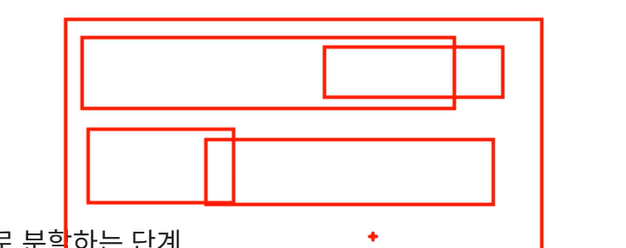 => data가 중복이 된다.
  - (3) 임베딩 (Embedding) / 인덱싱 (Indexing)
    - 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 단계
    - 분할된 텍스트를 검색 가능한 형태로 만드는 단계
  - (4) 검색(Retrieval)
    - 사용자의 질문이나 주어진 컨텍스트에 가장 관련된 정보를 찾아내는 단계
  - (5) 생성(Generation)
    - 검색된 정보를 바탕으로 사용자의 질문에 답변을 생성하는 최종 단계

## 2.1.데이터 로드(Load Data)
  - 외부 데이터 소스에서 정보를 수집하고, 필요한 형식으로 변환하여 시스템에 로드
  - 가져온 데이터는 검색에 사용될 지식이나 정보를 담고 있어야 함
  - (예) 공개 데이터셋, 웹 크롤링을 통해 얻은 데이터, 또는 사전에 정리된 자료 등



LangChain(0.2.x 계열) 기준 “데이터 로드”에 쓰기 좋은 **권장 로더**
### 2.1.1.PDF

* **일반 텍스트 추출(가볍고 빠름)**

  * `PyPDFLoader` (langchain\_community) — 표준 pypdf 기반.
    `pip install -U langchain_community pypdf`
* **레이아웃/이미지/표 추출까지(기능 풍부)**

  * `PyMuPDFLoader` (langchain\_community) — 이미지/표 추출 옵션, 페이지 단위 모드 지원.
    `pip install -U langchain_community pymupdf`
* **Unstructured 기반 파서(혼합 문서/스캔물 등)**

  * `UnstructuredPDFLoader` (langchain\_community) — 비정형 PDF에 강함.
    `pip install -U langchain-community unstructured`

### 2.1.2. HWP (한글)

* **전용 커뮤니티 로더**

  * `HWPLoader` (langchain-teddynote) — HWP를 텍스트로 로드.
    `pip install -U langchain-teddynote`
    사용 예: `from langchain_teddynote.document_loaders import HWPLoader`

### 2.1.3. CSV

* **행(row) 단위 로드(메타데이터 포함)**

  * `CSVLoader` (langchain\_community) — 구분자/필드명 등 `csv_args`로 제어.
    `pip install -U langchain_community`

### 2.1.4. Excel

* **Unstructured 기반 로더(간단·범용)**

  * `UnstructuredExcelLoader` (langchain\_community) — `.xls/.xlsx` 지원, `mode="elements"`로 시트/셀 요소화 가능.
    `pip install -U langchain_community unstructured`
* **판다스 → 데이터프레임 경유(열 지정 가능)**

  * `DataFrameLoader` + `pandas.read_excel()` — 특정 열을 본문으로 삼아 구조 보존에 유리.
    `pip install -U pandas langchain_community`
* *(레거시 대안)* 구조 보존 특화 외부 패키지: `langchain-excel-loader (StructuredExcelLoader)` — 시트별 문서화.
  `pip install langchain-excel-loader`

### 2.1.5. Word (.docx)

* **가벼운 로더**

  * `Docx2txtLoader` (langchain\_community) — 텍스트 중심 추출.
* **Unstructured 기반(요소 분리/메타데이터 풍부)**

  * `UnstructuredWordDocumentLoader` (langchain\_community) — `mode="elements"`로 제목/본문 등 분리.
    `pip install -U langchain_community unstructured docx2txt`

### 2.1.6. PowerPoint (.ppt/.pptx)

* **Unstructured 기반 로더**

  * `UnstructuredPowerPointLoader` (langchain\_community) — `.ppt/.pptx` 모두 지원, `mode="single" | "elements"`.
    `pip install -U langchain_community unstructured python-pptx python-magic`  

### 2.1.7. 웹 문서(HTML 등)

* **기본 웹 로더**

  * `WebBaseLoader` (langchain\_community) — HTML 전체 텍스트 로드, lazy/async 지원, 파서 교체 가능.
    `pip install -U langchain_community`
* **대량/크롤링 특화(옵션)**

  * 사이트맵 단위: `SitemapLoader` / 고급 크롤링: `FireCrawlLoader`, `SpiderLoader` (필요 시 고려).

### 2.1.8. 일반 텍스트

* **단순 텍스트 파일**

  * `TextLoader` (langchain\_community) — `.txt` 등 기본 텍스트 로드.
    `pip install -U langchain_community`

### 2.1.9. JSON

* **jq 스키마 기반 추출(정교한 필드 제어)**

  * `JSONLoader` (langchain\_community) — `jq_schema`로 본문/메타데이터 지정, lazy/async 지원.
    `pip install -U langchain_community jq`

---

### 2.1.10. 빠른 선택 가이드

* **표/이미지/레이아웃**이 중요한 PDF → **PyMuPDFLoader** / **UnstructuredPDFLoader**.
* **구조 보존**이 필요한 표 형식(CSV/Excel) → **CSVLoader**, **DataFrameLoader(+pandas)**.
* **HWP** → **HWPLoader (langchain-teddynote)**.
* **웹 페이지** → **WebBaseLoader**(필요 시 `default_parser="xml"` 등 파서 변경).


In [129]:
# from google.colab import drive
# drive.mount('/content/drive')

In [130]:
# %cd

- PDF 파일 읽기

```python
SPRi AI Brief 산업동향
- PRi(Software Policy & Research Institute, 소프트웨어정책연구소)
- 인공지능 산업 전반의 최신 정책·법제, 기업·산업 동향, 기술·연구 성과, 인력·교육 이슈를 매월 요약·정리한 브리핑 리포트
- 해외 주요 기관(EU, 미국, 일본 등)의 정책 발표, 글로벌 빅테크 기업의 신제품·서비스, 최신 연구 성과, 노동시장 변화 등을 빠르게 파악할 수 있는 산업 동향 브리프로 구성
```

In [131]:
# 해당 디렉토리 안에 모든 pdf 파일들을 읽어들이는 도구
from langchain_community.document_loaders import PyPDFDirectoryLoader

In [132]:
loader = PyPDFDirectoryLoader("./data/")
documents = loader.load()

In [133]:
len(documents) # 3개의 파일, 총 84ea의 페이지 

84

## 2.2. 텍스트 분할(Text Split)

> 토큰 (Token) : 텍스트를 구성하는 가장 작은 단위
- 보통 단어, 부분 단어, 구두점 등으로 분리됨

> 청크 (Chunk)
> - 여러 토큰을 하나의 의미 단위로 묶은 것
> - 문장 내 구(phrase)나 문장 단위로 의미 있는 그룹을 형성

- 청크의 활용:
  - 임베딩 생성: 각 청크에 대해 텍스트 임베딩을 생성하여 벡터화하고, 검색이나 유사도 계산에 활용함
  - 질의응답 시스템: 사용자의 질문과 관련된 청크를 찾아 응답을 생성함
  - 요약 생성: 청크별로 요약을 생성하고, 이를 종합하여 전체 문서의 요약을 만듬

### 2.2.1. 왜 텍스트를 분할해야 할까?
> - `Document Loader`를 사용하여 다양한 형식의 문서를 성공적으로 불러와도, 이 문서들은 아직 우리 챗봇이 '읽기'에는 너무 김
> - LLM은 한 번에 처리할 수 있는 텍스트의 양, 즉 <br>'컨텍스트 창(Context Window)'</br>에 제한이 있음
> - 예를 들어, `gpt-3.5-turbo` 모델은 약 4,096 토큰(대략 한글 2,000자) 정도를 한 번에 처리할 수 있음
> - 만약 우리가 100페이지짜리 PDF 파일 전체를 한 번에 LLM에게 전달한다면, LLM은 이 정보를 처리하지 못하고 오류를 발생시킬 것

```
비유: 한 입에 너무 큰 음식을 넣는 것과 같음
아무리 맛있는 음식이라도 한 번에 너무 많이 입에 넣으면 제대로 씹거나 삼킬 수 없음
잘게 썰어서 한 입 크기로 만들어야 맛있게 먹을 수 있듯이, 긴 문서도 LLM이 처리하기 좋은 '한 입 크기(청크, Chunk)'로 잘라주어야 함

이 역할을 하는 것이 바로 텍스트 분할기(Text Splitter)
```

---
### 2.2.2. 종류
- <font color=red>CharacterTextSplitter</font>
  - 주어진 텍스트를 설정한 단위로 분할하는 클래스
  - 예를 들어, 문단('\n\n'), 문장('\n'), 단어(빈 공백), 형태소 단위로 분할할 수 있음

- <font color=red>RecursiveCharacterTextSplitter</font> = 현재 가장 선호도가 높은 것으로 알려져 있음.
  - 텍스트를 재귀적으로 분할하여 의미적으로 관련 있는 텍스트 조각들이 함께 있도록 설계된 클래스
  - 분할 과정에서 지정된 <font color=red>문자 리스트(['\n\n', '\n', ' ', ''])를 순서대로 사용하여 텍스트를 분할</font>
  - 분할된 청크의 길이가 설정된 chunk_size보다 작아질 때까지 이 과정을 반복

- <font color=red>split_documents()</font>
  - 데이터 로더의 반환값에서 'page_content' 항목을 찾아서 청크로 분리하는 함수

- <font color=red>split_text()</font>
  - 데이터 로더의 반환값에서 'page_content' 항목만을 가져와 청크로 분리하는 함수
  - 반환값 구성
    - page_content : 분할된 토큰이 저장
    - metadata : 원본 문서에 대한 정보가 저장


- `RecursiveCharacterTextSplitter` (권장 방식)
- **작동 방식:** 이름 그대로 **'재귀적으로(Recursively)'** 작동하는, 훨씬 더 지능적인 분할기 → 문맥 유지를 최우선 목표로 함
- 재귀적(Recursive) = 재귀 함수: 함수가 자신의 본문에서 자기 자신을 다시 호출하며 문제를 푼다.
- **핵심 원리:** 개발자가 **문자 리스트(`separators`)**를 제공하면(기본값: `["\n\n", "\n", " ", ""]`), 그 순서대로 분할을 시도함
    1.  먼저, 문단 구분자인 `\n\n` (두 번의 줄바꿈)을 기준으로 텍스트를 나눔
    2.  나눠진 조각 중, 여전히 `chunk_size`보다 큰 조각이 있다면, 그 조각에 대해 다음 구분자인 `\n` (줄바꿈)을 기준으로 다시 나눔
    3.  그래도 `chunk_size`보다 큰 조각이 있다면, 다음 구분자인 ` ` (공백)을 기준으로 나눔
    4.  이 과정을 리스트의 마지막 구분자까지 반복함

> **비유: '큰 덩어리부터 작은 덩어리 순으로 썰기'**
> - 큰 고깃덩어리를 자를 때, 먼저 큰 뼈 사이를 자르고(문단 분리), 그래도 덩어리가 크면 살코기의 결을 따라 자르고(문장 분리), 마지막으로 한 입 크기로 써는(단어 분리) 것과 같음
> - 최대한 의미 있는 덩어리를 유지하려는 노력

In [134]:
from langchain.text_splitter import RecursiveCharacterTextSplitter # 텍스트 분할 도구

In [135]:
# 생성 
text_splitter = RecursiveCharacterTextSplitter(
    chunk_size = 1000, # 청크 크기 
    length_function = len, # 길이 측정 함수 => 길이값 계산의 기준(len() 활용)
    chunk_overlap = 100 # 청크 ★겹침★ 크기 
)

In [136]:
documents[3]

Document(metadata={'producer': 'Hancom PDF 1.3.0.505', 'creator': 'Hancom PDF 1.3.0.505', 'creationdate': '2025-05-09T09:07:04+09:00', 'author': 'dj', 'moddate': '2025-05-09T09:07:04+09:00', 'pdfversion': '1.4', 'source': 'data\\SPRi AI Brief 5월호 산업동향.pdf', 'total_pages': 28, 'page': 3, 'page_label': '4'}, page_content='SPRi AI Brief2025년 5월호\n2\n미국 백악관 예산관리국, 연방정부의 AI 활용 및 조달 관련 지침 2종 공개n미국 백악관 예산관리국은 트럼프 대통령의 AI 행정명령에 따라 연방 기관의 AI 활용 및 조달에 관한 개정된 지침을 발표nAI 활용 지침은 정부의 AI 도입 가속화와 혁신 주도를 강조하고 있으며, AI 조달 지침은 시장 경쟁을 통한 정부와 공공의 이익 보장 및 AI 성과와 위험관리, 효율적인 AI 조달을 중점 추구\nKEY Contents\n£백악관의 개정 지침, 연방정부의 AI 도입 가속화 및 효율적 AI 조달 추구n미국 백악관 예산관리국(OMB)이 2025년 4월 3일 트럼프 대통령의 2025년 1월 AI 행정명령*에 따라 바이든 전임 행정부의 지침을 대체할 새로운 지침 ‘M-25-21‘과 ‘M-25-22’를 공개* Executive Order 14179: Removing Barriers to American Leadership in Artificial Intelligence(2025.01.23.): 바이든 전 대통령의 AI 정책 폐기 및 새로운 AI 행동계획의 수립을 요구∙연방정부의 AI 활용 가속화에 관한 M-25-21은 전임 행정부의 M-24-10*을, 효율적인 AI 조달에 관한 M-25-22는 전임 행정부의 M-24-18**을 대체 * 연방정부 기관의 안전하고 

In [137]:
# 각 문서들을 청크로 분할
texts = text_splitter.split_documents(documents)

In [138]:
# 청크 개수 확인
len(texts) # 3개의 파일, 총 256개의 청크
for i, text in enumerate(texts[:5]) : 
    print(f"{i+1}번째 문서 청크 \n {text.page_content}\n ")

# enumerate 함수는 리스트, 튜플 등 반복 가능한 객체(iterable)를 반복할 때
# 각 요소의 인덱스(순서)와 값을 동시에 반환해주는 함수입니다.
# 예시:
# for idx, value in enumerate(['a', 'b', 'c']):
#     print(idx, value)
# 결과:
# 0 a
# 1 b
# 2 c

1번째 문서 청크 
 2025년5월호인공지능 산업의 최신 동향
 
2번째 문서 청크 
 SPRi AI Brief2025년 5월호
2
CONTENTS정책･법제∙미국 백악관 예산관리국, 연방정부의 AI 활용 및 조달 관련 지침 2종 공개2∙EU 집행위원회, EU의 AI 리더십을 위한 AI 대륙 행동계획 발표3∙아프리카 AI 정상회의, AI 아프리카 선언 발표 4∙미국 하원 중국특별위원회, 딥시크에 의한 국가안보 위협 제기5∙중국 정부, AI 중심의 디지털 교육 활성화 정책 지침 발표6기업･산업∙마이크로소프트·오픈AI·AWS 등 주요 기업, 앤스로픽의 MCP 프로토콜 채택8∙구글, AI 에이전트 간 통신 프로토콜 ‘A2A’ 공개 및 MCP 지원 발표9∙메타, 멀티모달 AI 모델 ‘라마 4’ 제품군 공개 및 성능 조작 의혹 부인10∙아마존, AI 에이전트 구축을 위한 AI 모델 ‘노바 액트’ 공개11∙오픈AI, GPT-4.1 API로 출시 및 o3와 o4-미니 출시 12∙샤오미 전기차 사망사고로 중국에서 자율주행 기능에 대한 우려 증대13∙포브스, 2025년 50대 AI 기업 목록 발표 14기술･연구∙UCSD 실험 결과, 오픈AI GPT-4.5가 튜링테스트 통과16∙AI 연구자들, 지능형 에이전트의 진화 형태와 도전과제 분석17∙METR 연구 결과, AI의 작업 능력은 7개월마다 2배씩 증가18∙마이크로소프트 연구진, 추론 향상을 위한 컴퓨팅 자원 투입 효과 분석19∙영국 AI보안연구소, AI 에이전트의 위험 완화를 위한 통제 프레임워크 제시20인력･교육 ∙퓨리서치센터 조사, 미국 대중과 AI 전문가 간 AI 인식 격차 확인22∙세일즈포스 조사 결과, 대다수 미국인은 정부 서비스의 AI 에이전트 도입 희망23∙지지통신 조사 결과, 일본 대기업의 30%가 채용 절차에 AI 도입 또는 도입 예정24주요행사일정25
| 2025년 5월호 |
 
3번째 문서 청크 
 | 2025년 5월호 |
정책･법제
 
4번째 문서 청크 
 SPRi AI Brief2025년 5월호
2
미국

## 2.3. 임베딩 (Embedding) / 인덱싱 (Indexing)
- 텍스트 데이터를 숫자로 이루어진 벡터로 변환하는 단계
- 분할된 텍스트를 검색 가능한 형태로 만드는 단계

In [139]:
# 벡터 DB 도구 활용
from langchain_openai import OpenAIEmbeddings
from langchain.vectorstores import Chroma # 벡터 DB 도구

In [140]:
vec_db = Chroma.from_documents(
    documents=texts,
    embedding=OpenAIEmbeddings()
)

In [141]:
# 검색 기능 설정 => 변수 담아야하는거 아냐? 
retriever = vec_db.as_retriever(
    search_kwargs={"k":2} # 상위 2개 문서 검색
)

- 벡터 저장소
  - 벡터 형태로 표현된 데이터, 즉 임베딩 벡터들을 효율적으로 저장하고 검색할 수 있는 시스템이나 데이터베이스
  - <font color=red>임베딩 결과를 벡터DB에 저장 </font>
  - FAISS, FAISS  비동기, Chroma, Pinecone 등

- 검색(Retrieval)
  - 사용자의 입력을 바탕으로 쿼리를 생성하고, 인덱싱된 데이터에서 가장 관련성 높은 정보를 검색
    - 벡터저장소 지원 검색기
    - 문맥 압축 검색기
    - 앙상블 검색기
    - 긴 문맥 재정렬
    - 상위 문서 검색기
    - 다중 쿼리 검색기
    - 셀프 쿼리 검색기
    - 시간 가중 벡터 저장소 검색기
    - 한글 형태소 분석기

## 2.4. 검색(Retrieval)
- 사용자의 질문이나 주어진 컨텍스트에 가장 관련된 정보를 찾아내는 단계

### 2.4.1. 기본 벡터 저장소 검색기 (Vector Store Retriever)
- 가장 기본적인 검색기
- 벡터 저장소의 `similarity_search` 기능을 그대로 사용하여, 질문과 가장 유사한 문서를 `k`개 찾아옴

```python
print(retriever.invoke("LangChain의 체인(Chain)은 무엇인가요?")[0].page_content)
```

### 2.4.2. Multi-Query 검색기
- 사용자의 질문이 때로는 너무 단순하거나 모호해서, 검색 결과가 좋지 않을 수 있음
- Multi-Query 검색기는 LLM을 사용하여 **사용자의 원래 질문을 여러 다른 관점의 유사한 질문들로 재구성**한 뒤, 이 모든 질문들을 벡터 저장소에 던져서 검색 결과를 종합하는 방식
- **비유:** 도서관 사서에게 "AI에 대해 알려주세요"라고 막연하게 묻는 대신, 사서가 스스로 "인공지능의 역사", "머신러닝의 원리", "최신 AI 기술 동향" 등 여러 구체적인 질문을 만들어서 책을 찾아보는 것과 같음

```python
from langchain.retrievers import MultiQueryRetriever

# MultiQueryRetriever를 생성합니다.
multi_query_retriever = MultiQueryRetriever.from_llm(
    retriever = retriever, # 기본 검색기
    llm = llm # 질문을 생성할 LLM
)

question = "LangChain의 에이전트(Agent)는 어떤 역할을 하나요?"
retrieved_docs_mq = multi_query_retriever.invoke(question)
```

### 2.4.3. Parent-Document 검색기
- 우리가 문서를 작은 청크로 나누는 이유는 효율적인 검색을 위해서임
- 하지만 너무 작은 청크만 LLM에게 전달하면, 문맥이 부족하여 답변의 품질이 떨어질 수 있음
- Parent-Document 검색기는 이 딜레마를 해결함

> **작동 원리: "검색은 작은 조각(자식)으로 정확하게, 답변은 전체 맥락(부모)을 보고 풍부하게!"**

1.  문서를 두 가지 크기, 즉 검색에 용이한 작은 **자식 청크(child chunk,key, index)**와, 풍부한 맥락을 담은 더 큰 **부모 청크(parent chunk, value, value)**로 나눔
2.  벡터 저장소에는 작은 '자식 청크'만 저장하여 검색 효율을 높임
3.  사용자 질문과 유사한 '자식 청크'를 찾은 뒤, 실제로 LLM에게 전달하는 것은 그 자식 청크가 속한 **'부모 청크' 전체**임

```python
from langchain.retrievers import ParentDocumentRetriever
from langchain.storage import InMemoryStore

# 1. 부모-자식 분할기 설정
parent_splitter = RecursiveCharacterTextSplitter(chunk_size=1000)
child_splitter = RecursiveCharacterTextSplitter(chunk_size=300)

# 2. 벡터 저장소와 문서 저장소(docstore) 설정
docstore = InMemoryStore()

# 3. ParentDocumentRetriever 생성
parent_document_retriever = ParentDocumentRetriever(
    vectorstore=vec_db,
    docstore=docstore,
    child_splitter=child_splitter,
    parent_splitter=parent_splitter,
)

# 4. 문서를 리트리버에 추가 (내부적으로 부모/자식 분할 및 저장이 일어남)
parent_document_retriever.add_documents(documents)

# 5. 검색 테스트
retrieved_docs_pd = parent_document_retriever.invoke("LangChain의 메모리 종류는?")
print(len(retrieved_docs_pd))
print(retrieved_docs_pd[0].page_content)
print(retrieved_docs_pd[1].page_content)
print(retrieved_docs_pd[2].page_content)
print(retrieved_docs_pd[3].page_content)
```

### 2.4.4. Self-Query 검색기
- 사용자의 자연어 질문에서 **검색할 내용**과 **필터링할 조건(메타데이터)**을 LLM을 사용하여 자동으로 분리하고, 이를 기반으로 검색을 수행하는 매우 지능적인 검색기
- 예를 들어, "5페이지에 있는 내용 중에서 체인에 대해 설명해줘" 라는 질문을 이해할 수 있음

```python
from langchain.chains.query_constructor.base import AttributeInfo
from langchain.retrievers.self_query.base import SelfQueryRetriever
import lark
# 1. 필터링할 메타데이터에 대한 정보를 정의합니다.
metadata_field_info = [
    AttributeInfo(name="page", description="문서의 페이지 번호", type="integer"),
]

# 2. 문서의 전체적인 내용에 대한 설명을 작성합니다.
document_content_description = "LangChain 프레임워크에 대한 설명서"

# 3. SelfQueryRetriever를 생성합니다.
self_query_retriever = SelfQueryRetriever.from_llm(
    llm, vec_db, document_content_description, metadata_field_info, verbose=True
)

# 4. 메타데이터 필터링이 포함된 질문을 테스트합니다.
question_with_filter = "10페이지에서 LangChain의 메모리에 대해 설명하는 내용을 찾아줘."
retrieved_docs_self_query = self_query_retriever.invoke(question_with_filter)

print(f"\n--- Self-Query 검색 결과 ---")
for doc in retrieved_docs_self_query:
    print(f"페이지: {doc.metadata['page']}, 내용: {doc.page_content[:100]}...")
```

### 2.4.5. 체인 기반의 RAG 구현 => 가장 좋다고 함?(선생님 추천)
- 가장 성능이 좋음!

- RetrievalQA 계열 체인은 검색기(retriever)에서 가져온 문서 청크들을 LLM에 전달할 때, 이를 하나의 문자열로 합쳐서 prompt에 넣어줌
- 그 자리에 들어가는 키워드가 보통 context, summaries 같은 이름
- 여기서는 "이 시스템은 PDF 문서를 분석하여, 관련 정보와 문맥을 미리 파악한 후 {summaries}" → 검색된 문서 내용이 {summaries} 자리에 삽입

```
사용자가 query = "분야별 평균 단가는?" 질문을 던지면:
retriever가 문서 DB에서 관련 청크 2~3개를 가져옴
RetrievalQA 체인이 이 청크들을 하나의 텍스트로 합쳐서 {summaries}에 주입
```

In [142]:
from langchain.chains import RetrievalQAWithSourcesChain # 검색 QA체인을 만들 수 있는 도구


- 대화형 프롬프트 템플릿 설정

In [143]:
# 메세지 리스트 & 메세지 템플릿 생성
messages = [

    # 답변을 만들어낼때 청크들을 기반으로 해서 답변을 만들어 낼 것이다.
    # summaries : RetrievalQA 계열의 체인들은 검색기에서 가져온 청크들을 LLM한테 전달할 때, 하나의 문자열로 합쳐서 prompt에 전달함
    ("system", "이 시스템은 PDF 문서를 분석해서, 관련 정보와 문맥을 미리 파악한다! {summaries}"),
    ("user", "{question}")
]

chat_prompt = ChatPromptTemplate.from_messages(messages)

- 문서 검색기 기반 chain 생성

In [144]:
chain = RetrievalQAWithSourcesChain.from_chain_type(
    llm = LLM,              # 위에서 만든 LLM
    chain_type = "stuff",   # 청크들을 하나의 문자열로 합쳐서 prompt에 전달(stuff) => 그대로 결합할때 쓰인다
    retriever = retriever,  # 벡터 DB로 만든 검색기 => (★★ 순서를 지정할때는 키워드 매개변수, 순서 그대로 쓸꺼면 그냥 매개변수만 넣으면 된다 )
    return_source_documents = False, # 응답에 원본 문서를 포함하지 않겠다. 
    chain_type_kwargs = {"prompt": chat_prompt} # 프롬프트 템플릿 지정 => 메시지 템플릿 전달 (template -> prompt)
)

## 2.5. 생성(Generation)
- 검색된 정보를 바탕으로 사용자의 질문에 답변을 생성하는 최종 단계

In [145]:
result = chain.invoke("LangChain의 체인(Chain)은 무엇인가요?")
result

{'question': 'LangChain의 체인(Chain)은 무엇인가요?',
 'answer': 'LangChain에서 체인(Chain)은 여러 개의 구성 요소(예: 프롬프트, LLM, 도구 등)를 순차적으로 연결하여 복잡한 작업을 수행할 수 있도록 하는 구조를 의미합니다. 즉, 체인은 여러 단계를 거쳐 입력을 처리하고, 각 단계의 출력을 다음 단계의 입력으로 사용하여 최종 결과를 생성하는 일련의 작업 흐름입니다.\n\n예를 들어, 사용자가 자연어 질문을 입력하면, 체인은 이를 적절한 프롬프트로 변환하고, LLM에 전달하여 답변을 생성한 뒤, 필요에 따라 후처리하거나 추가 도구를 호출하는 등의 여러 단계를 포함할 수 있습니다.\n\n따라서 LangChain의 체인은 복잡한 언어 모델 기반 애플리케이션을 구성할 때, 여러 기능을 조합하고 자동화하는 데 핵심적인 역할을 합니다.',
 'sources': ''}

In [ ]:
result = chain.invoke("구글 딥마인드가 발표한 알파이볼브는 어떤 연구야?")

In [147]:
LLM.invoke("구글 딥마인드가 발표한 알파이볼브는 어떤 연구야?")

AIMessage(content='구글 딥마인드가 발표한 **알파이볼브(AlphaFold)**는 단백질의 3차원 구조를 예측하는 인공지능(AI) 연구입니다. 단백질은 생명체 내에서 매우 중요한 역할을 하는 분자인데, 그 기능은 단백질의 3차원 구조에 크게 의존합니다. 하지만 단백질의 3차원 구조를 실험적으로 규명하는 것은 시간과 비용이 많이 드는 어려운 작업입니다.\n\n딥마인드의 알파이볼브는 딥러닝 기술을 활용해 단백질의 아미노산 서열(1차 구조)만으로 단백질의 3차원 구조를 매우 정확하게 예측할 수 있도록 개발되었습니다. 2020년에 발표된 이 연구는 단백질 구조 예측 분야에서 획기적인 성과로 평가받았으며, 생명과학, 의약품 개발, 생물학 연구 등 다양한 분야에 큰 영향을 미치고 있습니다.\n\n주요 특징은 다음과 같습니다:\n- 단백질 서열 정보를 입력받아 3차원 구조를 예측\n- 기존 방법보다 훨씬 빠르고 정확한 예측 성능\n- 전 세계 수많은 단백질 구조를 예측해 공개함으로써 연구자들이 쉽게 활용 가능\n\n알파이볼브는 단백질 구조 예측 문제를 해결함으로써 생명과학 연구의 패러다임을 바꾸는 중요한 도구로 자리잡고 있습니다.', additional_kwargs={'refusal': None}, response_metadata={'token_usage': {'completion_tokens': 330, 'prompt_tokens': 27, 'total_tokens': 357, 'completion_tokens_details': {'accepted_prediction_tokens': 0, 'audio_tokens': 0, 'reasoning_tokens': 0, 'rejected_prediction_tokens': 0}, 'prompt_tokens_details': {'audio_tokens': 0, 'cached_tokens': 0}}, 'model_name': 'gpt-4.1-mini-2025-04-14', 'system_fingerprint': 'fp